In [2]:
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("aiml_salary.csv")

In [4]:
print(df.head(10))
print(df.shape)

      job_id             job_title      job_category  experience_level  \
0  AIJOB0001    AI Agent Developer    AI Engineering  Senior (6-9 yrs)   
1  AIJOB0002       Prompt Engineer    AI Engineering  Senior (6-9 yrs)   
2  AIJOB0003          LLM Engineer    AI Engineering  Senior (6-9 yrs)   
3  AIJOB0004    Data Engineer (AI)  Data Engineering  Senior (6-9 yrs)   
4  AIJOB0005    AI Product Manager           Product    Lead (10+ yrs)   
5  AIJOB0006    AI Agent Developer    AI Engineering   Entry (0-2 yrs)   
6  AIJOB0007  AI Security Engineer          Security     Mid (3-5 yrs)   
7  AIJOB0008    Senior ML Engineer    AI Engineering     Mid (3-5 yrs)   
8  AIJOB0009          NLP Engineer    AI Engineering   Entry (0-2 yrs)   
9  AIJOB0010       Prompt Engineer    AI Engineering   Entry (0-2 yrs)   

   years_of_experience    education_required  annual_salary_usd  \
0                    7              Master's           239000.0   
1                    2            Bachelor's       

Before working on the data we will clean the data or reduce it by removing(dropping) 
unneseccary columns from the df so that the input feature reduces making the model or code more easy to use (user friendly) or  easy for working on it.
And then we will find and drop null and duplicate values

In [5]:
df=df.drop(["job_id","job_title","city","posting_year","posting_month","is_remote_friendly","is_llm_role"], axis=1)
print("Cleaned dataset size : ",df.shape)
df.head()



Cleaned dataset size :  (1500, 18)


,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_senior,salary_tier
0,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,1,Senior ($200-300k)
1,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,1,Upper-Mid ($150-200k)
2,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,1,Elite (>$300k)
3,Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,1,Upper-Mid ($150-200k)
4,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,1,Senior ($200-300k)


In [6]:
df.head()


,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_senior,salary_tier
0,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,1,Senior ($200-300k)
1,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,1,Upper-Mid ($150-200k)
2,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,1,Elite (>$300k)
3,Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,1,Upper-Mid ($150-200k)
4,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,1,Senior ($200-300k)


I chose this AI Jobs dataset because AI/ML is in hype right now. 
Many freshers don’t know about salary ranges, required skills, or what factors affect pay in the AI field. 
This dataset helps predict salary and understand the job market better.
The continuos values i want to predict are :
1) annual_salary_usd - main target (Output feature) 
2) salary_min_usd 
3) salary_max_usd

In [7]:
missing_data= df.isnull().sum()
missing_data_per = (missing_data/len(df))*100
print("Sum of missing data : \n",missing_data)
print("\nPercentage of missing data : \n",missing_data_per)
duplicates_sum =df.duplicated().sum()
print("Sum of duplicate values in the dataset : ",duplicates_sum)
if duplicates_sum!=0:
    df = df.drop_duplicates()
    print("Duplicate values are dropped!")

#Steps:
#1) found the sum of missing(null) values using isnull().sum()
#2) Calcutated percentage of null values using (missing_data/len(df))*100
#3) Checked sum of duplicate values using duplicates_sum =df.duplicated().sum()
#4) Droped the duplicate values using drop_duplicates if any

#Observation
#1) No missing values found → All columns have 0% missing data
#2) No duplicate rows found → Dataset is clean. No rows were dropped.



Sum of missing data : 
 job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
is_senior                0
salary_tier              0
dtype: int64

Percentage of missing data : 
 job_category             0.0
experience_level         0.0
years_of_experience      0.0
education_required       0.0
annual_salary_usd        0.0
salary_min_usd           0.0
salary_max_usd           0.0
country                  0.0
remote_work              0.0
company_size             0.0
industry                 0.0
required_skills          0.0
ai_salary_premium_pct    0.0
demand_score             0.0
demand_growth_yoy_pct    0.0
benefits_s

In [8]:
print("Statistical information of the dataset : ")
print(df.describe().round(2))

#Observation :
#1) The average annual salary in the aiml field is -> 194892.00
#2) The minimum annual salary in the aiml field is -> 90000.00
#3) The maximum annual salary in the aiml field is -> 384000.00
#4) The average years of experience required in the aiml field is -> 6.22 years
#5) The minimum years of experience required in the aiml field is -> 1.00 years          




Statistical information of the dataset : 
       years_of_experience  annual_salary_usd  salary_min_usd  salary_max_usd  \
count              1500.00            1500.00         1500.00         1500.00   
mean                  6.22          194892.00       135448.67       257537.33   
std                   2.68           66506.82        24448.95        39852.82   
min                   1.00           90000.00        90000.00       180000.00   
25%                   4.00          144750.00       120000.00       218000.00   
50%                   6.00          180000.00       140000.00       270000.00   
75%                   8.00          236250.00       155000.00       290000.00   
max                  15.00          384000.00       180000.00       320000.00   

       ai_salary_premium_pct  demand_score  demand_growth_yoy_pct  \
count                1500.00       1500.00                1500.00   
mean                   10.86         87.52                  31.12   
std                  

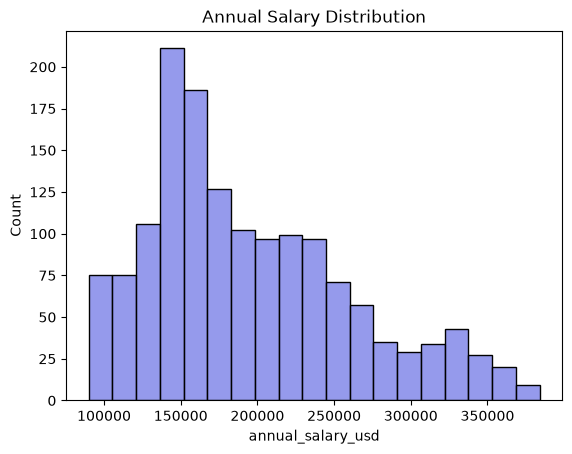

In [9]:
numerical_df = df[["years_of_experience", "annual_salary_usd", "salary_min_usd", "salary_max_usd","ai_salary_premium_pct", "demand_score", "demand_growth_yoy_pct", "benefits_score_10"]]
#hisplot of annual_salary_usd -> target variable
sns.histplot(data = numerical_df,x="annual_salary_usd",color="#7278e6")
plt.title("Annual Salary Distribution")
plt.show()

#Detailed Insights:
#1) Near 75 People have annual salary of 100000
#2) 150000 is the most frequent salary with over 200 people
#3) 


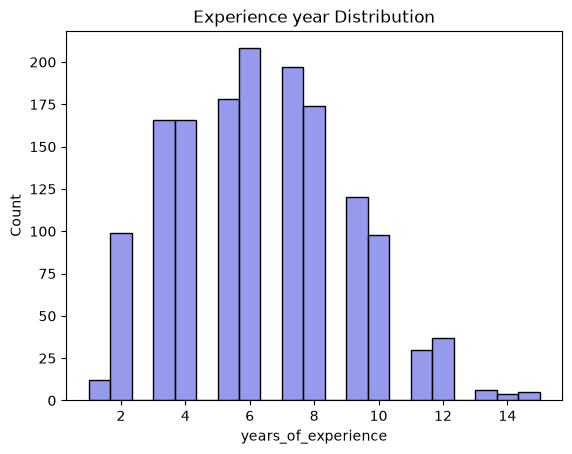

In [10]:
#hisplot of years_of_experience
sns.histplot(data = numerical_df,x="years_of_experience",color="#7278e6")
plt.title("Experience year Distribution")
plt.show()

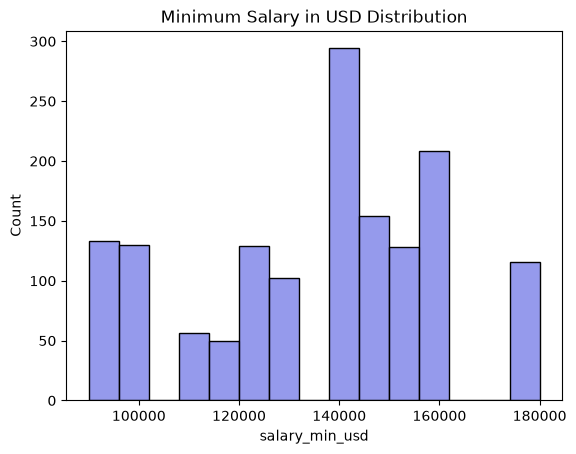

In [11]:
#hisplot of salary_min_usd->target variable
sns.histplot(data = numerical_df,x="salary_min_usd",color="#7278e6")
plt.title("Minimum Salary in USD Distribution")
plt.show()

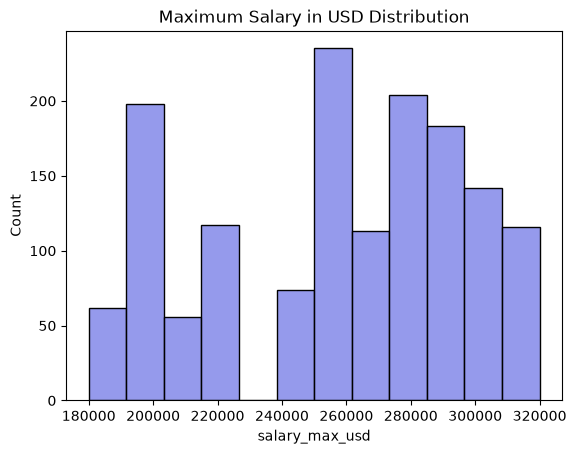

In [12]:
#hisplot of salary_max_usd->target variable
sns.histplot(data = numerical_df,x="salary_max_usd",color="#7278e6")
plt.title("Maximum Salary in USD Distribution")
plt.show()

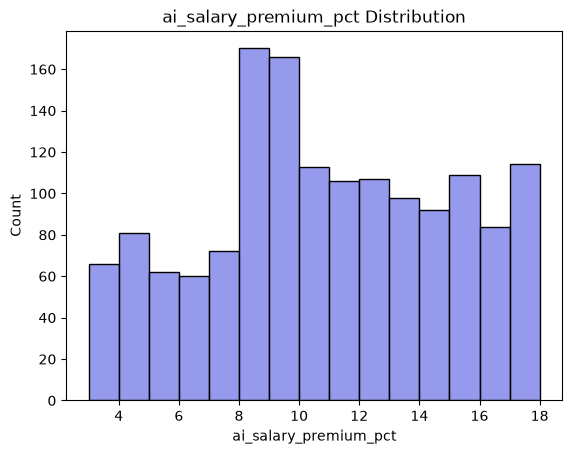

In [13]:
#hisplot of ai_salary_premium_pct
sns.histplot(data = numerical_df,x="ai_salary_premium_pct",color="#7278e6")
plt.title("ai_salary_premium_pct Distribution")
plt.show()

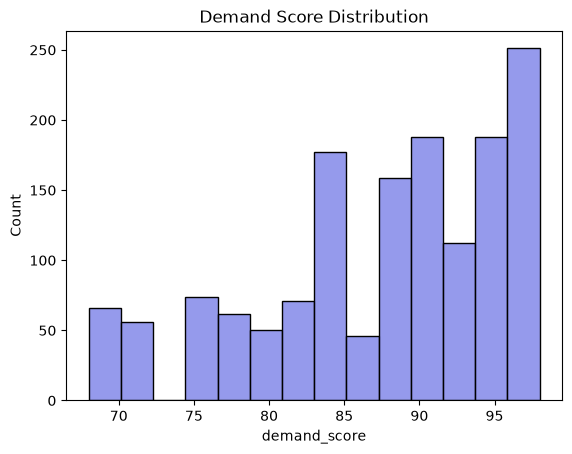

In [14]:
#hisplot of demand_score
sns.histplot(data = numerical_df,x="demand_score",color="#7278e6")
plt.title("Demand Score Distribution")
plt.show()

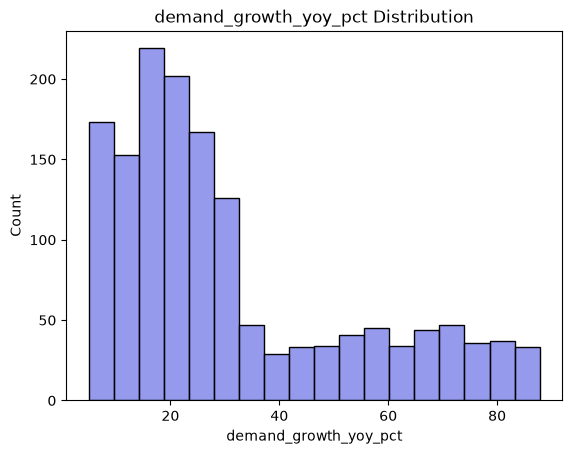

In [15]:
#hisplot of demand_growth_yoy_pct
sns.histplot(data = numerical_df,x="demand_growth_yoy_pct",color="#7278e6")
plt.title("demand_growth_yoy_pct Distribution")
plt.show()

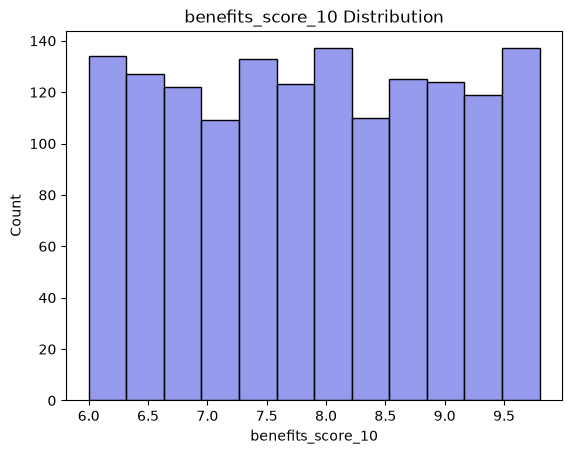

In [16]:
#hisplot of benefits_score_10
sns.histplot(data = numerical_df,x="benefits_score_10",color="#7278e6")
plt.title("benefits_score_10 Distribution")
plt.show()

In [17]:
categorial_df=df[["education_required","country","remote_work","company_size","industry","is_senior","salary_tier"]]


In [18]:
df.columns

Index(['job_category', 'experience_level', 'years_of_experience',
       'education_required', 'annual_salary_usd', 'salary_min_usd',
       'salary_max_usd', 'country', 'remote_work', 'company_size', 'industry',
       'required_skills', 'ai_salary_premium_pct', 'demand_score',
       'demand_growth_yoy_pct', 'benefits_score_10', 'is_senior',
       'salary_tier'],
      dtype='str')

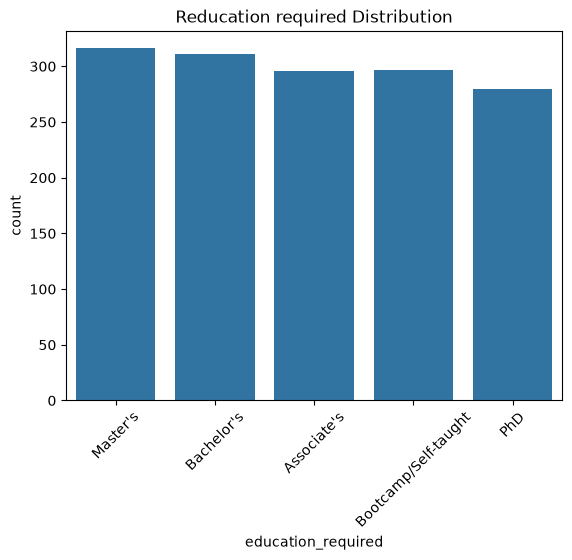

In [19]:
sns.countplot(data=df,x="education_required",)
plt.title("Reducation required Distribution")
plt.xticks(rotation =45)
plt.show()

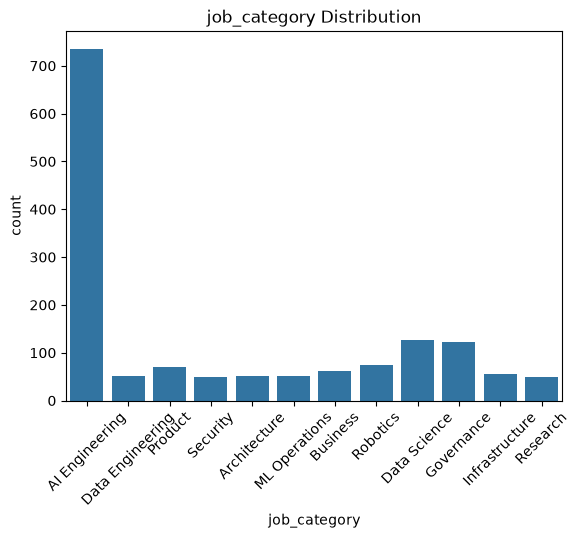

In [20]:
sns.countplot(data=df,x="job_category",)
plt.title("job_category Distribution")
plt.xticks(rotation =45)
plt.show()

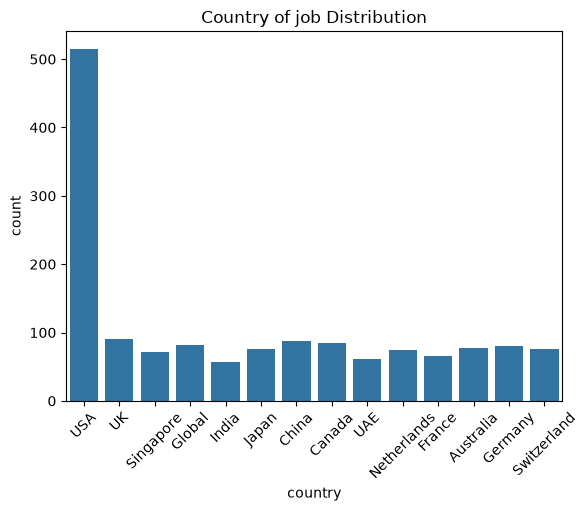

In [21]:
sns.countplot(data=df,x="country",)
plt.title("Country of job Distribution")
plt.xticks(rotation =45)
plt.show()

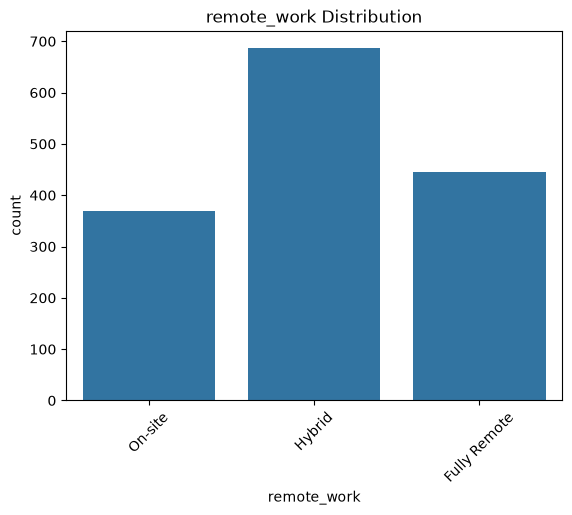

In [22]:
sns.countplot(data=df,x="remote_work",)
plt.title("remote_work Distribution")
plt.xticks(rotation =45)
plt.show()

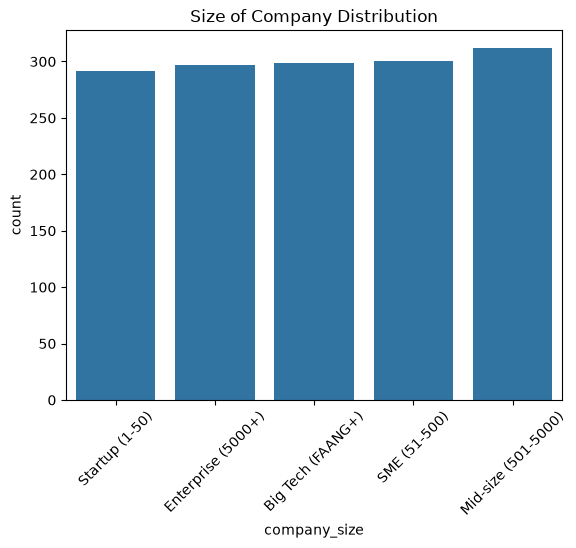

In [23]:
sns.countplot(data=df,x="company_size",)
plt.title("Size of Company Distribution")
plt.xticks(rotation =45)
plt.show()

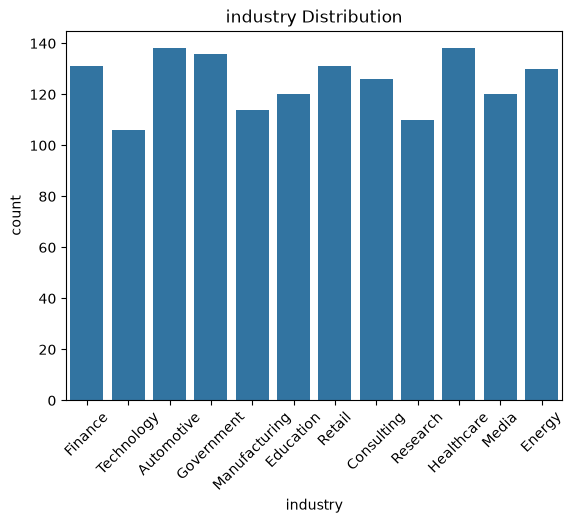

In [24]:
sns.countplot(data=df,x="industry")
plt.title("industry Distribution")
plt.xticks(rotation =45)
plt.show()

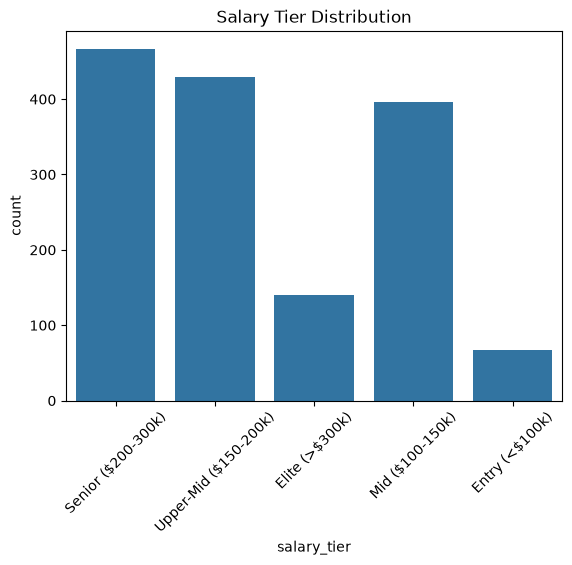

In [25]:
sns.countplot(data=df,x="salary_tier")
plt.title("Salary Tier Distribution")
plt.xticks(rotation =45)
plt.show()

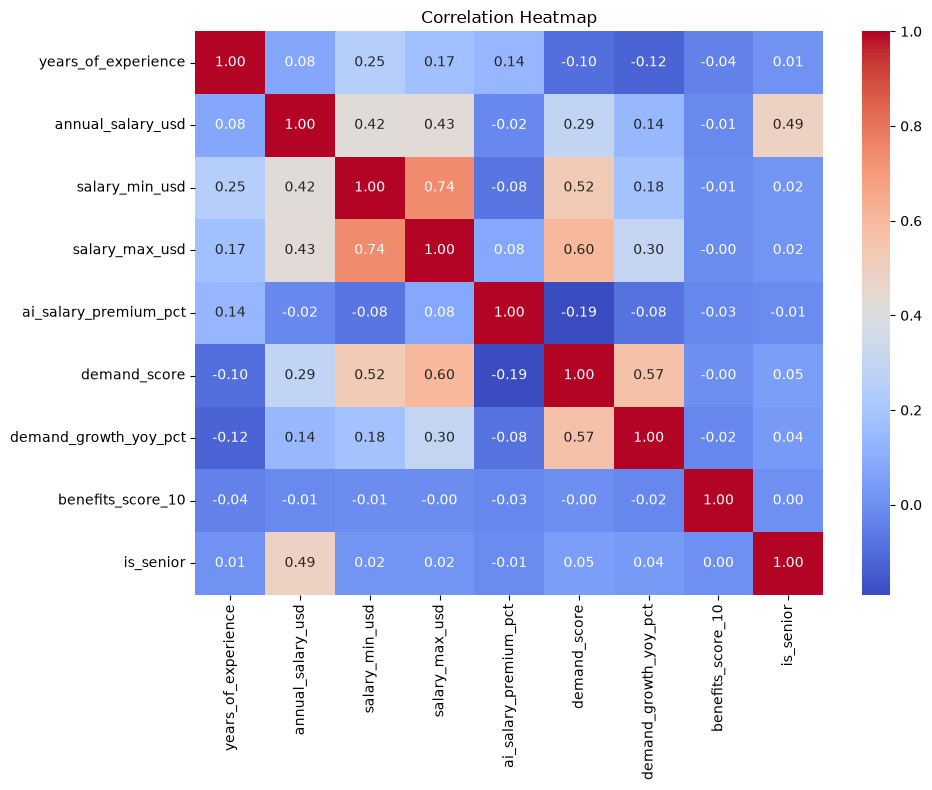

In [26]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
y=df[["annual_salary_usd","salary_min_usd","salary_max_usd"]]#target value
X=df.drop(["annual_salary_usd","salary_min_usd","salary_max_usd"],axis=1)#input values


In [28]:
df.head(2)

,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_senior,salary_tier
0,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,1,Senior ($200-300k)
1,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,1,Upper-Mid ($150-200k)
